# Red Sea W. Coast Saudi — bypass journey trace

Since **20 Jul 2026** Houthis announced strikes on crude loadings from West Coast Saudi Arabia transiting Bab el Mandeb.

**Patterns tracked**
1. **full_cycle** — W. Coast load → Ain Sukhna discharge → Sidi Kerir reload → final destination
2. **sidi_topup** — W. Coast **partial** load (Suez-constrained, &lt;65% capacity) → Sidi Kerir top-up (no Ain Sukhna)
3. **ain_sukhna_only** — W. Coast load → Ain Sukhna, no Sidi Kerir reload / Suez exit within **7 days**
4. **in_progress** — incomplete legs or still inside the 7-day window
5. **other** — W. Coast load not aimed at these patterns

Volume evidence drives a daily time series of bypassed / topped-up kbbl.

**Kernel:** repo `.venv`. Credentials from `vessel_crossing/.env`.


## 1. Setup & config

In [1]:
from __future__ import annotations

import sys
import warnings
from datetime import date, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:  # script / plain python
    display = print  # type: ignore

HERE = Path(r"C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\red_sea_yanbu_bypass")
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import importlib
import config as cfg

cfg = importlib.reload(cfg)  # pick up config.py edits without kernel restart

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 56)
pd.set_option("display.width", 180)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

cfg.OUT_DIR.mkdir(parents=True, exist_ok=True)

AS_OF = date.today()
PULL_START = cfg.START_DATE - timedelta(days=cfg.LOOKBACK_DAYS)
PULL_END = AS_OF + timedelta(days=cfg.FORWARD_DAYS)

print(f"Window: {cfg.START_DATE} -> {AS_OF}  (pull {PULL_START} -> {PULL_END})")
print(f"Ain-Sukhna-only lag: {cfg.AIN_SUKHNA_ONLY_DAYS}d")


Window: 2026-07-16 -> 2026-08-11  (pull 2026-07-09 -> 2026-09-25)
Ain-Sukhna-only lag: 7d


## 2. Helpers

In [2]:
import importlib

cfg = importlib.reload(cfg)  # ensure latest config.py knobs (e.g. VLCC_PARTIAL_KBBL_FALLBACK)

def parse_env(path: Path) -> dict[str, str]:
    """Load KEY=value .env without printing secrets."""
    out: dict[str, str] = {}
    if not path.exists():
        return out
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        k, v = line.split("=", 1)
        out[k.strip()] = v.strip()
    return out


def clean_str(value) -> str:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return ""
    text = str(value).strip()
    return "" if text.lower() in {"", "nan", "none"} else text


def to_number(s: pd.Series) -> pd.Series:
    return pd.to_numeric(
        s.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce",
    )


def matches_any(text: str, aliases: tuple[str, ...]) -> bool:
    t = (text or "").lower()
    return any(a in t for a in aliases)


def first_match_col(row: pd.Series, cols: tuple[str, ...]) -> str:
    for c in cols:
        if c in row.index:
            txt = clean_str(row.get(c))
            if txt:
                return txt
    return ""


def origin_blob(row: pd.Series) -> str:
    parts = [clean_str(row.get(c)) for c in cfg.ORIGIN_COLS if c in row.index]
    return " | ".join(p for p in parts if p)


def dest_blob(row: pd.Series) -> str:
    return first_match_col(row, cfg.DEST_COLS)


def is_wcoast_origin(row: pd.Series) -> bool:
    return matches_any(origin_blob(row), cfg.W_COAST_ORIGIN_KEYWORDS)


def is_ain_sukhna(text: str) -> bool:
    return matches_any(text, cfg.AIN_SUKHNA_ALIASES)


def is_sidi_kerir(text: str) -> bool:
    return matches_any(text, cfg.SIDI_KERIR_ALIASES)


def is_suez_like(text: str) -> bool:
    # Avoid matching "Suezmax" vessel class strings by requiring location-ish tokens
    t = (text or "").lower()
    if "suezmax" in t:
        return False
    return matches_any(t, cfg.SUEZ_EXIT_ALIASES)


def trade_load_ts(row: pd.Series) -> pd.Timestamp:
    for col in ("origin_start", "origin_eta_date", "start"):
        if col in row.index and pd.notna(row.get(col)):
            return pd.Timestamp(row.get(col))
    return pd.NaT


def trade_discharge_ts(row: pd.Series) -> pd.Timestamp:
    for col in ("destination_start", "destination_end", "destination_eta", "end"):
        if col in row.index and pd.notna(row.get(col)):
            return pd.Timestamp(row.get(col))
    return pd.NaT


def bbl_to_kbbl(s: pd.Series) -> pd.Series:
    return to_number(s) / 1000.0




def status_to_realization(status: str) -> str:
    """Scheduled = forecast; Loading / In Transit / Delivered = realized."""
    s = (status or "").strip().lower()
    if s == "scheduled":
        return "forecast"
    if s in {"loading", "in transit", "delivered"}:
        return "realized"
    return "forecast" if s else "forecast"



def collapse_journeys(detail: pd.DataFrame) -> pd.DataFrame:
    """One row per (imo, load_date) for charts/stats.

    Kpler cargo-splits duplicate the same Sidi reload onto every split row.
    Collapse sums load volumes once and keeps Sidi / Ain leg volumes once.
    """
    if detail is None or detail.empty:
        return detail.copy()

    df = detail.copy()
    df["_imo_key"] = pd.to_numeric(df["imo"], errors="coerce")
    df["_load_key"] = pd.to_datetime(df["load_date"], errors="coerce").dt.normalize()

    status_rank = {
        "delivered": 0,
        "in transit": 1,
        "loading": 2,
        "scheduled": 3,
    }
    class_rank = {
        "full_cycle": 0,
        "sidi_topup": 1,
        "ain_sukhna_only": 2,
        "in_progress": 3,
        "other": 4,
    }
    real_rank = {"realized": 0, "forecast": 1}

    df["_status_rank"] = df["load_status"].astype(str).str.lower().map(status_rank).fillna(9)
    df["_class_rank"] = df["classification"].map(class_rank).fillna(9)
    df["_real_rank"] = df["realization"].map(real_rank).fillna(9)

    rows = []
    for (_, _), g in df.groupby(["_imo_key", "_load_key"], dropna=False):
        g = g.sort_values(["_status_rank", "_class_rank", "load_kbbl"], ascending=[True, True, False])
        primary = g.iloc[0]

        def first_notna(col: str):
            if col not in g.columns:
                return primary.get(col)
            s = g[col].dropna()
            return s.iloc[0] if len(s) else primary.get(col)

        # Sidi / Ain volumes: take once (max of non-null), never sum — splits repeat the same Sidi kbbl
        def once_num(col: str):
            if col not in g.columns:
                return np.nan
            s = pd.to_numeric(g[col], errors="coerce").dropna()
            return float(s.max()) if len(s) else np.nan

        rec = primary.to_dict()
        rec["load_kbbl"] = float(pd.to_numeric(g["load_kbbl"], errors="coerce").fillna(0).sum())
        rec["ain_discharge_kbbl"] = once_num("ain_discharge_kbbl")
        rec["sidi_reload_kbbl"] = once_num("sidi_reload_kbbl")
        rec["capacity_kbbl"] = once_num("capacity_kbbl")
        rec["fill_ratio"] = (
            rec["load_kbbl"] / rec["capacity_kbbl"]
            if pd.notna(rec["capacity_kbbl"]) and rec["capacity_kbbl"] > 0
            else np.nan
        )
        rec["residual_onboard_kbbl"] = (
            rec["load_kbbl"] - rec["ain_discharge_kbbl"]
            if pd.notna(rec["ain_discharge_kbbl"])
            else np.nan
        )
        # Prefer strongest class / realization seen in the split group
        rec["classification"] = g.sort_values("_class_rank").iloc[0]["classification"]
        rec["realization"] = g.sort_values("_real_rank").iloc[0]["realization"]
        rec["load_status"] = g.sort_values("_status_rank").iloc[0]["load_status"]
        rec["n_trade_splits"] = int(len(g))
        # Keep leg timestamps from first non-null
        for col in (
            "ain_ts", "ain_date", "ain_source", "ain_place",
            "sidi_ts", "sidi_date", "sidi_dest", "sidi_status", "sidi_source",
            "suez_ts", "suez_date", "suez_place", "final_destination",
            "nominated_dest", "origin", "grade", "vessel_class", "capacity_kbbl", "fill_ratio",
        ):
            if col in g.columns:
                rec[col] = first_notna(col)
        rows.append(rec)

    out = pd.DataFrame(rows)
    drop_cols = [c for c in out.columns if c.startswith("_")]
    return out.drop(columns=drop_cols, errors="ignore").reset_index(drop=True)




def capacity_m3_to_kbbl(m3) -> float:
    """Kpler vessel_capacity_cubic_meters -> kbbl."""
    val = pd.to_numeric(m3, errors="coerce")
    if pd.isna(val) or val <= 0:
        return np.nan
    return float(val) * cfg.M3_TO_BBL / 1000.0


def is_partial_wcoast_load(load_kbbl, capacity_kbbl, vessel_class: str = "") -> bool:
    """True if W. Coast lifting looks Suez-constrained (below PARTIAL_CAPACITY_FRAC)."""
    load = pd.to_numeric(load_kbbl, errors="coerce")
    if pd.isna(load) or load <= 0:
        return False
    cap = pd.to_numeric(capacity_kbbl, errors="coerce")
    if pd.notna(cap) and cap > 0:
        return float(load) / float(cap) < cfg.PARTIAL_CAPACITY_FRAC
    vc = (vessel_class or "").lower()
    if "vlcc" in vc or "ulcc" in vc:
        return float(load) < cfg.VLCC_PARTIAL_KBBL_FALLBACK
    return False




def dest_region_bucket(
    dest: str = "",
    country: str = "",
    continent: str = "",
    subcontinent: str = "",
) -> str:
    """Bucket destinations into USA / Europe / Asia / Other / (blank)."""
    d = (dest or "").strip().lower()
    c = (country or "").strip().lower()
    cont = (continent or "").strip().lower()
    sub = (subcontinent or "").strip().lower()
    blob = " | ".join(x for x in (d, c, cont, sub) if x)

    if not blob:
        return "(blank)"

    # USA / US Gulf signals (before generic "america")
    usa_hits = (
        "united states",
        "usa",
        "u.s.",
        "houston",
        "louisiana",
        "loop",
        "port arthur",
        "corpus christi",
        "americas",  # Kpler often uses this for US-bound
    )
    if any(h in blob for h in usa_hits) and "south america" not in blob and "latin" not in blob:
        return "USA"
    if cont == "north america" and "mexico" not in blob and "canada" not in blob:
        return "USA"
    if c in {"united states", "usa"}:
        return "USA"

    if cont == "europe" or "europe" in d or "europe" in sub:
        return "Europe"
    if any(
        h in blob
        for h in (
            "netherlands",
            "rotterdam",
            "france",
            "spain",
            "italy",
            "greece",
            "uk",
            "united kingdom",
            "germany",
            "portugal",
            "turkey",
            "mediterranean",
        )
    ):
        return "Europe"

    if cont == "asia" or "asia" in d or "asia" in sub:
        return "Asia"
    if any(
        h in blob
        for h in (
            "china",
            "india",
            "korea",
            "japan",
            "taiwan",
            "singapore",
            "thailand",
            "malaysia",
            "pakistan",
            "indonesia",
            "vietnam",
            "philippines",
            "mundra",
            "jamnagar",
            "ulsan",
            "qingdao",
            "ningbo",
        )
    ):
        return "Asia"

    return "Other"


print("Helpers ready.")


Helpers ready.


## 3. Kpler auth

In [3]:
cred = parse_env(cfg.ENV_PATH)
email = cred.get("KPLER_EMAIL") or cred.get("EMAIL")
password = cred.get("KPLER_PASSWORD") or cred.get("PASSWORD")
assert email and password, f"Missing KPLER_EMAIL / KPLER_PASSWORD in {cfg.ENV_PATH}"

from kpler.sdk import Platform, TradesStatus
from kpler.sdk.configuration import Configuration
from kpler.sdk.resources.port_calls import PortCalls
from kpler.sdk.resources.trades import Trades

kpler_cfg = Configuration(Platform.Liquids, email, password)
trades_client = Trades(kpler_cfg)
port_calls_client = PortCalls(kpler_cfg)

TRADE_STATUSES = [
    TradesStatus.Scheduled,
    TradesStatus.Loading,
    TradesStatus.InTransit,
    TradesStatus.Delivered,
]

print("Kpler clients ready.")

c:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\.venv\Lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Kpler clients ready.


## 4. Pull Saudi crude trades → keep W. Coast origins

Country-level `Saudi Arabia` pull (intra-country on), then keyword-filter to Red Sea / West Coast terminals.

In [4]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    trades_sa = trades_client.get(
        products=[cfg.PRODUCT],
        from_zones=cfg.FROM_ZONES,
        start_date=PULL_START,
        end_date=PULL_END,
        with_forecast=True,
        with_intra_country=True,
        with_intra_region=True,
        trade_status=TRADE_STATUSES,
        columns=cfg.TRADE_COLS,
        size=10000,
    )

if trades_sa is None or trades_sa.empty:
    raise RuntimeError("No Saudi Arabia crude trades returned — check credentials / window.")

trades_sa = trades_sa.copy()
for col in ("start", "end", "origin_start", "origin_end", "origin_eta_date",
            "destination_start", "destination_end", "destination_eta"):
    if col in trades_sa.columns:
        trades_sa[col] = pd.to_datetime(trades_sa[col], errors="coerce")

trades_sa["vessel_imo"] = pd.to_numeric(trades_sa["vessel_imo"], errors="coerce").astype("Int64")
trades_sa["load_ts"] = trades_sa.apply(trade_load_ts, axis=1)
trades_sa["discharge_ts"] = trades_sa.apply(trade_discharge_ts, axis=1)
trades_sa["origin_best"] = trades_sa.apply(lambda r: first_match_col(r, cfg.ORIGIN_COLS), axis=1)
trades_sa["dest_best"] = trades_sa.apply(dest_blob, axis=1)
trades_sa["kbbl"] = bbl_to_kbbl(trades_sa["cargo_origin_barrels_split_by_product"])
if "vessel_capacity_cubic_meters" in trades_sa.columns:
    trades_sa["capacity_kbbl"] = trades_sa["vessel_capacity_cubic_meters"].map(capacity_m3_to_kbbl)
else:
    trades_sa["capacity_kbbl"] = np.nan
    print("WARN: vessel_capacity_cubic_meters missing from Trades pull — re-run setup to reload TRADE_COLS")
trades_sa["is_wcoast"] = trades_sa.apply(is_wcoast_origin, axis=1)
trades_sa["dest_ain_sukhna"] = trades_sa["dest_best"].map(is_ain_sukhna)
trades_sa["dest_country"] = (
    trades_sa["destination_country_name"].map(clean_str)
    if "destination_country_name" in trades_sa.columns
    else ""
)
trades_sa["dest_continent"] = (
    trades_sa["continent_destination_name"].map(clean_str)
    if "continent_destination_name" in trades_sa.columns
    else ""
)
trades_sa["dest_subcontinent"] = (
    trades_sa["destination_subcontinent_name"].map(clean_str)
    if "destination_subcontinent_name" in trades_sa.columns
    else ""
)
trades_sa["dest_region"] = [
    dest_region_bucket(
        r.get("dest_best", ""),
        r.get("dest_country", ""),
        r.get("dest_continent", ""),
        r.get("dest_subcontinent", ""),
    )
    for _, r in trades_sa.iterrows()
]
trades_sa["origin_sidi"] = trades_sa["origin_best"].map(is_sidi_kerir)
trades_sa["origin_ain"] = trades_sa["origin_best"].map(is_ain_sukhna)

wcoast = trades_sa[trades_sa["is_wcoast"]].copy()
# Analysis universe: loads on/after announcement
universe = wcoast[wcoast["load_ts"].dt.date >= cfg.START_DATE].copy()
universe = universe.sort_values(["load_ts", "vessel_name"]).reset_index(drop=True)

print(f"Saudi crude trades: {len(trades_sa):,}")
print(f"W. Coast (all pull): {len(wcoast):,}  |  universe since {cfg.START_DATE}: {len(universe):,}")
print("Origins:")
print(universe["origin_best"].value_counts().head(15).to_string())
print("\nDestinations (top):")
print(universe["dest_best"].value_counts().head(15).to_string())
print("\nStatus:")
print(universe["status"].value_counts().to_string())
print(f"\nDestined Ain Sukhna: {universe['dest_ain_sukhna'].sum():,} / {len(universe):,}")


Saudi crude trades: 102
W. Coast (all pull): 90  |  universe since 2026-07-16: 64
Origins:
origin_best
Yanbu Crude    26
Muajjiz        23
Yanbu          15

Destinations (top):
dest_best
Ain Sukhna                    20
                              10
Ulsan                          3
New Mangalore Refinery         2
Karachi Keamari                2
BORL Jamnagar Oil Terminal     2
Eastern Asia                   2
Petronas Melaka Refinery       1
Houston                        1
CNPC Qinzhou Refinery          1
Jizan Refinery                 1
Huizhou                        1
Kaohsiung                      1
Taoyuan                        1
Chennai                        1

Status:
status
Delivered     26
In Transit    26
Scheduled     12

Destined Ain Sukhna: 20 / 64


## 5. Follow-on legs — Ain Sukhna discharges + Sidi Kerir reloads + port calls

Zone pulls are more reliable than IMO filters (`vessels=` needs names). We also pull vessel-name chunks for extra legs.


In [5]:
def _normalize_trades(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame(columns=cfg.TRADE_COLS)
    out = df.copy()
    for col in (
        "start", "end", "origin_start", "origin_end", "origin_eta_date",
        "destination_start", "destination_end", "destination_eta",
    ):
        if col in out.columns:
            out[col] = pd.to_datetime(out[col], errors="coerce")
    out["vessel_imo"] = pd.to_numeric(out.get("vessel_imo"), errors="coerce").astype("Int64")
    out["load_ts"] = out.apply(trade_load_ts, axis=1)
    out["discharge_ts"] = out.apply(trade_discharge_ts, axis=1)
    out["origin_best"] = out.apply(lambda r: first_match_col(r, cfg.ORIGIN_COLS), axis=1)
    out["dest_best"] = out.apply(dest_blob, axis=1)
    out["kbbl"] = bbl_to_kbbl(out["cargo_origin_barrels_split_by_product"])
    out["origin_sidi"] = out["origin_best"].map(is_sidi_kerir)
    out["dest_ain_sukhna"] = out["dest_best"].map(is_ain_sukhna)
    if "destination_country_name" in out.columns:
        out["dest_country"] = out["destination_country_name"].map(clean_str)
    else:
        out["dest_country"] = ""
    if "continent_destination_name" in out.columns:
        out["dest_continent"] = out["continent_destination_name"].map(clean_str)
    else:
        out["dest_continent"] = ""
    if "destination_subcontinent_name" in out.columns:
        out["dest_subcontinent"] = out["destination_subcontinent_name"].map(clean_str)
    else:
        out["dest_subcontinent"] = ""
    out["dest_region"] = [
        dest_region_bucket(
            r.get("dest_best", ""),
            r.get("dest_country", ""),
            r.get("dest_continent", ""),
            r.get("dest_subcontinent", ""),
        )
        for _, r in out.iterrows()
    ]
    return out


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # All crude into Ain Sukhna (discharge / SUMED intake side)
    ain_dest_trades = _normalize_trades(
        trades_client.get(
            products=[cfg.PRODUCT],
            to_zones=["Ain Sukhna"],
            start_date=PULL_START,
            end_date=PULL_END,
            with_forecast=True,
            with_intra_country=True,
            with_intra_region=True,
            trade_status=TRADE_STATUSES,
            columns=cfg.TRADE_COLS,
            size=10000,
        )
    )
    # All crude loading Sidi Kerir (Med reload / SUMED outturn)
    sidi_loads = _normalize_trades(
        trades_client.get(
            products=[cfg.PRODUCT],
            from_zones=["Sidi Kerir"],
            start_date=PULL_START,
            end_date=PULL_END,
            with_forecast=True,
            with_intra_country=True,
            with_intra_region=True,
            trade_status=TRADE_STATUSES,
            columns=cfg.TRADE_COLS,
            size=10000,
        )
    )

# Optional: vessel-name chunks for any extra post-Yanbu legs (API wants strings, not IMOs)
names = sorted({clean_str(x) for x in universe["vessel_name"].dropna().unique() if clean_str(x)})
follow_frames: list[pd.DataFrame] = []
CHUNK = 40
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i in range(0, max(len(names), 1), CHUNK):
        chunk = names[i : i + CHUNK]
        if not chunk:
            break
        df = trades_client.get(
            products=[cfg.PRODUCT],
            vessels=chunk,
            start_date=PULL_START,
            end_date=PULL_END,
            with_forecast=True,
            with_intra_country=True,
            with_intra_region=True,
            trade_status=TRADE_STATUSES,
            columns=cfg.TRADE_COLS,
            size=10000,
        )
        if df is not None and not df.empty:
            follow_frames.append(df)

vessel_trades = _normalize_trades(pd.concat(follow_frames, ignore_index=True) if follow_frames else pd.DataFrame())

print(f"Ain Sukhna destination trades: {len(ain_dest_trades):,}")
print(f"Sidi Kerir origin loads: {len(sidi_loads):,}")
print(f"Vessel-name scoped trades: {len(vessel_trades):,}  ({len(names)} names)")
if not sidi_loads.empty:
    print("Sidi Kerir dest top:")
    print(sidi_loads["dest_best"].value_counts().head(12).to_string())


Ain Sukhna destination trades: 34
Sidi Kerir origin loads: 68
Vessel-name scoped trades: 87  (51 names)
Sidi Kerir dest top:
dest_best
Gdansk                          7
Gdansk Naftoport PERN           7
Trieste                         5
Tupras Aliaga Izmir Refinery    5
Butinge                         3
Sonatrach Augusta Refinery      3
Gibraltar-San Roque Refinery    3
Houston                         3
Pachi                           3
PBF Paulsboro                   2
Europe                          2
STAR Refinery                   2


In [6]:
def fetch_port_calls_zone(zone: str) -> pd.DataFrame:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df = port_calls_client.get(
            products=[cfg.PRODUCT],
            zones=[zone],
            start_date=PULL_START,
            end_date=PULL_END,
            with_forecast=True,
            columns=cfg.PORT_CALL_COLS,
            size=10000,
        )
    if df is None or df.empty:
        return pd.DataFrame(columns=cfg.PORT_CALL_COLS)
    out = df.copy()
    for col in ("start", "end"):
        if col in out.columns:
            out[col] = pd.to_datetime(out[col], errors="coerce")
    out["vessel_imo"] = pd.to_numeric(out["vessel_imo"], errors="coerce").astype("Int64")
    out["kbbl"] = bbl_to_kbbl(out["cargo_origin_barrels_split_by_product"])
    out["place"] = (
        out.get("installation_name", pd.Series("", index=out.index)).fillna("").astype(str)
        + " | "
        + out.get("location_name", pd.Series("", index=out.index)).fillna("").astype(str)
        + " | "
        + out.get("zone_name", pd.Series("", index=out.index)).fillna("").astype(str)
    )
    out["query_zone"] = zone
    return out


# Zone names as commonly used in Kpler UI — failures just yield empty frames
PC_ZONES = ["Ain Sukhna", "Sidi Kerir", "Suez", "Port Said"]
pc_frames = []
for z in PC_ZONES:
    try:
        pc = fetch_port_calls_zone(z)
        print(f"PortCalls {z}: {len(pc):,}")
        pc_frames.append(pc)
    except Exception as exc:  # noqa: BLE001 — zone name may not resolve
        print(f"PortCalls {z}: FAILED ({exc})")

port_calls = pd.concat(pc_frames, ignore_index=True) if pc_frames else pd.DataFrame()
if not port_calls.empty:
    port_calls["is_ain"] = port_calls["place"].map(is_ain_sukhna) | port_calls["query_zone"].map(is_ain_sukhna)
    port_calls["is_sidi"] = port_calls["place"].map(is_sidi_kerir) | port_calls["query_zone"].map(is_sidi_kerir)
    port_calls["is_suez"] = port_calls["place"].map(is_suez_like) | port_calls["query_zone"].str.lower().isin(
        {"suez", "port said"}
    )
else:
    print("No port calls returned.")

pc_ain = port_calls[port_calls["is_ain"]].copy() if not port_calls.empty else port_calls
pc_sidi = port_calls[port_calls["is_sidi"]].copy() if not port_calls.empty else port_calls
pc_suez = port_calls[port_calls["is_suez"]].copy() if not port_calls.empty else port_calls
print(f"Filtered PC — Ain: {len(pc_ain):,}  Sidi: {len(pc_sidi):,}  Suez-like: {len(pc_suez):,}")

PortCalls Ain Sukhna: 39
PortCalls Sidi Kerir: 67
PortCalls Suez: 0
PortCalls Port Said: 1
Filtered PC — Ain: 39  Sidi: 67  Suez-like: 1


C:\Users\luiscarlos.gaitan\AppData\Local\Temp\ipykernel_71300\1160480828.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  port_calls = pd.concat(pc_frames, ignore_index=True) if pc_frames else pd.DataFrame()
C:\Users\luiscarlos.gaitan\AppData\Local\Temp\ipykernel_71300\1160480828.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  port_calls = pd.concat(pc_frames, ignore_index=True) if pc_frames else pd.DataFrame()
C:\Users\luiscarlos.gaitan\AppData\Local\Temp\ipykernel_71300\1160480828.py:

## 6. Build journey chains + classify

One row per W. Coast load in the universe. Legs resolved by IMO + time order.

**Volume fields (kbbl)**
- `load_kbbl` — W. Coast load
- `ain_discharge_kbbl` — best available Ain Sukhna discharge / delivered volume
- `sidi_reload_kbbl` — Sidi Kerir reload (bypass re-entry to Med market)
- `residual_onboard_kbbl` — `load_kbbl - ain_discharge_kbbl` when both known (partial-discharge signal)

In [7]:
def _imo_slice(df: pd.DataFrame, imo: int | None) -> pd.DataFrame:
    if df is None or df.empty or imo is None or pd.isna(imo):
        return pd.DataFrame()
    return df[df["vessel_imo"] == int(imo)].copy()


def resolve_ain_discharge(imo: int | None, load_ts: pd.Timestamp, anchor: pd.Series) -> dict:
    """Prefer realized destination timestamps; fall back to PortCalls at Ain Sukhna."""
    out = {
        "ain_ts": pd.NaT,
        "ain_kbbl": np.nan,
        "ain_source": "",
        "ain_place": "",
    }
    # 1) Anchor trade itself destined to Ain Sukhna
    if bool(anchor.get("dest_ain_sukhna")):
        ts = anchor.get("discharge_ts")
        if pd.isna(ts):
            ts = anchor.get("end")
        out.update(
            {
                "ain_ts": ts,
                "ain_kbbl": float(anchor["kbbl"]) if pd.notna(anchor.get("kbbl")) else np.nan,
                "ain_source": "trade_dest",
                "ain_place": clean_str(anchor.get("dest_best")),
            }
        )

    # 2) Dedicated Ain Sukhna destination trades for this IMO after load
    ads = _imo_slice(ain_dest_trades, imo)
    if not ads.empty and pd.notna(load_ts):
        ads = ads[ads["load_ts"] >= load_ts - pd.Timedelta(days=2)].sort_values("load_ts")
        if not ads.empty:
            row = ads.iloc[0]
            ts = row["discharge_ts"] if pd.notna(row.get("discharge_ts")) else row.get("end")
            if pd.isna(out["ain_ts"]) or (pd.notna(ts) and (pd.isna(out["ain_ts"]) or ts <= out["ain_ts"])):
                out["ain_ts"] = ts
                out["ain_place"] = clean_str(row.get("dest_best"))
                out["ain_source"] = (
                    "ain_dest_trade"
                    if out["ain_source"] == ""
                    else f"{out['ain_source']}+ain_dest_trade"
                )
                if pd.notna(row.get("kbbl")):
                    out["ain_kbbl"] = float(row["kbbl"])

    # 3) Port call after load
    pcs = _imo_slice(pc_ain, imo)
    if not pcs.empty and pd.notna(load_ts):
        pcs = pcs[pcs["start"] >= load_ts - pd.Timedelta(days=1)].sort_values("start")
        if not pcs.empty:
            row = pcs.iloc[0]
            # Port-call volume is often the load remaining / call size — keep if we lack trade dest vol
            if pd.isna(out["ain_ts"]) or (pd.notna(row["start"]) and (pd.isna(out["ain_ts"]) or row["start"] <= out["ain_ts"])):
                out["ain_ts"] = row["start"]
                out["ain_place"] = clean_str(row.get("place"))
                out["ain_source"] = "port_call" if out["ain_source"] == "" else f"{out['ain_source']}+port_call"
                if pd.isna(out["ain_kbbl"]) and pd.notna(row.get("kbbl")):
                    out["ain_kbbl"] = float(row["kbbl"])

    return out


def resolve_sidi_reload(imo: int | None, after_ts: pd.Timestamp) -> dict:
    out = {
        "sidi_ts": pd.NaT,
        "sidi_kbbl": np.nan,
        "sidi_dest": "",
        "sidi_status": "",
        "sidi_source": "",
    }
    if pd.isna(after_ts):
        # Still allow search from load if Ain not dated yet — caller passes load_ts as fallback
        pass

    vt = _imo_slice(sidi_loads if not sidi_loads.empty else vessel_trades, imo)
    if not vt.empty:
        if "origin_sidi" in vt.columns:
            vt = vt[vt["origin_sidi"]]
        else:
            vt = vt[vt["origin_best"].map(is_sidi_kerir)]
        if pd.notna(after_ts):
            vt = vt[vt["load_ts"] >= after_ts - pd.Timedelta(days=1)]
        vt = vt.sort_values("load_ts")
        if not vt.empty:
            row = vt.iloc[0]
            out.update(
                {
                    "sidi_ts": row["load_ts"],
                    "sidi_kbbl": float(row["kbbl"]) if pd.notna(row.get("kbbl")) else np.nan,
                    "sidi_dest": clean_str(row.get("dest_best")),
                    "sidi_status": clean_str(row.get("status")),
                    "sidi_source": "trade",
                }
            )
            return out

    pcs = _imo_slice(pc_sidi, imo)
    if not pcs.empty:
        if pd.notna(after_ts):
            pcs = pcs[pcs["start"] >= after_ts - pd.Timedelta(days=1)]
        pcs = pcs.sort_values("start")
        if not pcs.empty:
            row = pcs.iloc[0]
            out.update(
                {
                    "sidi_ts": row["start"],
                    "sidi_kbbl": float(row["kbbl"]) if pd.notna(row.get("kbbl")) else np.nan,
                    "sidi_dest": "",
                    "sidi_status": "",
                    "sidi_source": "port_call",
                }
            )
    return out


def resolve_suez_exit(imo: int | None, after_ts: pd.Timestamp) -> dict:
    out = {"suez_ts": pd.NaT, "suez_place": "", "suez_source": ""}
    pcs = _imo_slice(pc_suez, imo)
    if pcs.empty:
        return out
    if pd.notna(after_ts):
        pcs = pcs[pcs["start"] >= after_ts - pd.Timedelta(days=1)]
    pcs = pcs.sort_values("start")
    if pcs.empty:
        return out
    row = pcs.iloc[0]
    out.update(
        {
            "suez_ts": row["start"],
            "suez_place": clean_str(row.get("place")),
            "suez_source": "port_call",
        }
    )
    return out


def classify_row(r: dict, as_of: date) -> str:
    has_ain = pd.notna(r.get("ain_ts")) or bool(r.get("dest_ain_sukhna"))
    has_sidi = pd.notna(r.get("sidi_ts"))
    has_suez = pd.notna(r.get("suez_ts"))
    partial = is_partial_wcoast_load(
        r.get("load_kbbl"), r.get("capacity_kbbl"), str(r.get("vessel_class") or "")
    )

    if has_ain and has_sidi:
        return "full_cycle"

    # Partial W. Coast load + later Sidi top-up, no Ain Sukhna (Suez-constrained VLCC pattern)
    if has_sidi and not has_ain and partial:
        return "sidi_topup"

    if has_ain and not has_sidi:
        ain_d = pd.Timestamp(r["ain_ts"]).date() if pd.notna(r.get("ain_ts")) else None
        if ain_d is None:
            # Nominated to Ain but not yet timed — treat as in progress
            return "in_progress" if bool(r.get("dest_ain_sukhna")) else "other"
        age = (as_of - ain_d).days
        if has_suez:
            # Exited Suez without a Sidi reload observed yet
            return "in_progress" if age <= cfg.AIN_SUKHNA_ONLY_DAYS else "other"
        if age <= cfg.AIN_SUKHNA_ONLY_DAYS:
            return "in_progress"
        return "ain_sukhna_only"

    if bool(r.get("dest_ain_sukhna")):
        return "in_progress"
    return "other"


rows = []
for _, anchor in universe.iterrows():
    imo = anchor["vessel_imo"] if pd.notna(anchor["vessel_imo"]) else None
    load_ts = anchor["load_ts"]
    ain = resolve_ain_discharge(imo, load_ts, anchor)
    after = ain["ain_ts"] if pd.notna(ain["ain_ts"]) else load_ts
    sidi = resolve_sidi_reload(imo, after)
    suez = resolve_suez_exit(imo, after)

    load_kbbl = float(anchor["kbbl"]) if pd.notna(anchor.get("kbbl")) else np.nan
    ain_kbbl = ain["ain_kbbl"]
    residual = (
        load_kbbl - ain_kbbl
        if pd.notna(load_kbbl) and pd.notna(ain_kbbl)
        else np.nan
    )

    rec = {
        "load_date": load_ts.date() if pd.notna(load_ts) else None,
        "vessel": clean_str(anchor.get("vessel_name")),
        "imo": int(imo) if imo is not None and not pd.isna(imo) else pd.NA,
        "vessel_class": clean_str(anchor.get("vessel_type")),
        "grade": clean_str(anchor.get("closest_ancestor_grade")) or clean_str(anchor.get("closest_ancestor_product")),
        "origin": clean_str(anchor.get("origin_best")),
        "load_status": clean_str(anchor.get("status")),
        "load_kbbl": load_kbbl,
        "capacity_kbbl": capacity_m3_to_kbbl(
            anchor.get("vessel_capacity_cubic_meters")
        ),
        "nominated_dest": clean_str(anchor.get("dest_best")),
        "dest_ain_sukhna": bool(anchor.get("dest_ain_sukhna")),
        "ain_ts": ain["ain_ts"],
        "ain_date": pd.Timestamp(ain["ain_ts"]).date() if pd.notna(ain["ain_ts"]) else None,
        "ain_discharge_kbbl": ain_kbbl,
        "ain_source": ain["ain_source"],
        "ain_place": ain["ain_place"],
        "residual_onboard_kbbl": residual,
        "sidi_ts": sidi["sidi_ts"],
        "sidi_date": pd.Timestamp(sidi["sidi_ts"]).date() if pd.notna(sidi["sidi_ts"]) else None,
        "sidi_reload_kbbl": sidi["sidi_kbbl"],
        "sidi_dest": sidi["sidi_dest"],
        "sidi_status": sidi["sidi_status"],
        "sidi_source": sidi["sidi_source"],
        "suez_ts": suez["suez_ts"],
        "suez_date": pd.Timestamp(suez["suez_ts"]).date() if pd.notna(suez["suez_ts"]) else None,
        "suez_place": suez["suez_place"],
        # Prefer Sidi-leg dest for completed cycles; else nominated dest only if NOT an Ain path
        "final_destination": (
            sidi["sidi_dest"]
            if sidi["sidi_dest"]
            else (
                ""
                if bool(anchor.get("dest_ain_sukhna")) or pd.notna(ain["ain_ts"])
                else clean_str(anchor.get("dest_best"))
            )
        ),
    }
    rec["fill_ratio"] = (
        rec["load_kbbl"] / rec["capacity_kbbl"]
        if pd.notna(rec.get("capacity_kbbl")) and rec["capacity_kbbl"] > 0 and pd.notna(rec.get("load_kbbl"))
        else np.nan
    )
    rec["classification"] = classify_row(rec, AS_OF)
    rec["realization"] = status_to_realization(rec.get("load_status", ""))
    rows.append(rec)

chains_detail = pd.DataFrame(rows)
# Guarantee capacity fields exist (older row builders / missing Kpler col)
if "capacity_kbbl" not in chains_detail.columns:
    if "vessel_capacity_cubic_meters" in chains_detail.columns:
        chains_detail["capacity_kbbl"] = chains_detail["vessel_capacity_cubic_meters"].map(
            capacity_m3_to_kbbl
        )
    else:
        chains_detail["capacity_kbbl"] = np.nan
if "fill_ratio" not in chains_detail.columns:
    chains_detail["fill_ratio"] = np.where(
        pd.to_numeric(chains_detail["capacity_kbbl"], errors="coerce").fillna(0) > 0,
        pd.to_numeric(chains_detail["load_kbbl"], errors="coerce")
        / pd.to_numeric(chains_detail["capacity_kbbl"], errors="coerce"),
        np.nan,
    )
# Charts / volume stats use collapsed journeys (one row per IMO x load_date).
# Export keeps chains_detail so cargo-split rows remain available.
chains = collapse_journeys(chains_detail)
# Re-classify on collapsed load_kbbl so partial fill uses the full lifting, not cargo splits
chains["fill_ratio"] = np.where(
    pd.to_numeric(chains["capacity_kbbl"], errors="coerce").fillna(0) > 0,
    pd.to_numeric(chains["load_kbbl"], errors="coerce")
    / pd.to_numeric(chains["capacity_kbbl"], errors="coerce"),
    np.nan,
)
chains["classification"] = [
    classify_row(row.to_dict(), AS_OF) for _, row in chains.iterrows()
]
chains["realization"] = chains["load_status"].map(status_to_realization)

print(f"Detail rows: {len(chains_detail):,}  |  Collapsed journeys: {len(chains):,}")
print(f"Splits collapsed away: {len(chains_detail) - len(chains):,}")
print("\n--- journeys (collapsed, used in charts) ---")
print(chains["classification"].value_counts().to_string())
print("\nRealization:")
print(chains["realization"].value_counts().to_string())
print(chains.groupby(["classification", "realization"], dropna=False)["load_kbbl"].sum().round(0).unstack(fill_value=0).to_string())
print("\nVolume by class (load_kbbl):")
print(chains.groupby("classification", dropna=False)["load_kbbl"].sum().round(0).to_string())
sidi_mask = chains["classification"].isin(cfg.SIDI_VOLUME_CLASSES)
print("\nSidi volume classes", cfg.SIDI_VOLUME_CLASSES, "kbbl:",
      round(chains.loc[sidi_mask, "sidi_reload_kbbl"].sum(), 1))
print(chains.loc[sidi_mask, ["vessel", "load_date", "load_kbbl", "capacity_kbbl", "fill_ratio",
                             "sidi_reload_kbbl", "classification"]].to_string())


Detail rows: 64  |  Collapsed journeys: 58
Splits collapsed away: 6

--- journeys (collapsed, used in charts) ---
classification
other              34
ain_sukhna_only    11
in_progress         7
sidi_topup          4
full_cycle          2

Realization:
realization
realized    46
forecast    12
realization      forecast  realized
classification                     
ain_sukhna_only       0.0   23158.0
full_cycle            0.0    4180.0
in_progress           0.0   14408.0
other             21275.0   26665.0
sidi_topup            0.0    4488.0

Volume by class (load_kbbl):
classification
ain_sukhna_only    23158.0
full_cycle          4180.0
in_progress        14408.0
other              47940.0
sidi_topup          4488.0

Sidi volume classes ('full_cycle', 'sidi_topup') kbbl: 5315.3
          vessel   load_date  load_kbbl  capacity_kbbl  fill_ratio  sidi_reload_kbbl classification
2    Dht Gazelle  2026-07-23   1081.935    2033.203009    0.532133           612.407     sidi_topup
19  Olympi

In [8]:
# Preview = collapsed journeys (chart universe). Full splits remain in chains_detail.
show_cols = [
    "load_date", "vessel", "vessel_class", "origin", "load_kbbl", "capacity_kbbl", "fill_ratio", "nominated_dest",
    "ain_date", "ain_discharge_kbbl", "sidi_date", "sidi_reload_kbbl", "sidi_dest",
    "suez_date", "final_destination", "classification", "realization", "load_status", "n_trade_splits",
]
_order = {"realized": 0, "forecast": 1}
chains_view = (
    chains[show_cols]
    .assign(_r=lambda d: d["realization"].map(_order).fillna(9))
    .sort_values(["_r", "load_date", "vessel"])
    .drop(columns="_r")
    .reset_index(drop=True)
)
chains_view


,load_date,vessel,vessel_class,origin,load_kbbl,capacity_kbbl,fill_ratio,nominated_dest,ain_date,ain_discharge_kbbl,sidi_date,sidi_reload_kbbl,sidi_dest,suez_date,final_destination,classification,realization,load_status,n_trade_splits
0,2026-07-16,Adebola Adeline,LR3,Yanbu Crude,213.828,1053.881149,0.202896,Petronas Melaka Refinery,None,NaN,None,NaN,,None,Petronas Melaka Refinery,other,realized,Delivered,1
1,2026-07-16,Niban,VLCC,Yanbu Crude,2130.553,2162.993032,0.985002,Ain Sukhna,2026-07-22,2130.553,None,NaN,,None,,ain_sukhna_only,realized,Delivered,1
2,2026-07-16,Sea Emerald,VLCC,Muajjiz,1996.460,2026.862891,0.985000,Taoyuan,None,NaN,None,NaN,,None,Taoyuan,other,realized,In Transit,2
3,2026-07-17,Amzan,VLCC,Muajjiz,2141.428,2174.037921,0.985000,Ain Sukhna,2026-07-21,2141.428,None,NaN,,None,,ain_sukhna_only,realized,Delivered,1
4,2026-07-17,Front Gaula,VLCC,Yanbu Crude,2057.264,2088.590988,0.985001,Ain Sukhna,2026-07-21,964.611,2026-07-27,964.611,Houston,None,Houston,full_cycle,realized,Delivered,2
5,2026-07-17,Sophia,VLCC,Muajjiz,2128.660,2161.074643,0.985001,Ulsan,None,NaN,None,NaN,,None,Ulsan,other,realized,In Transit,1
6,2026-07-18,Cosnew Lake,VLCC,Yanbu Crude,2135.000,2167.509109,0.985002,Huizhou,None,NaN,None,NaN,,None,Huizhou,other,realized,In Transit,1
7,2026-07-18,Merbabu,LR2,Yanbu Crude,716.214,727.119749,0.985001,New Mangalore Refinery,None,NaN,None,NaN,,None,New Mangalore Refinery,other,realized,Delivered,1
8,2026-07-18,Xin Long Yang,VLCC,Yanbu Crude,2055.742,2087.043697,0.985002,CNPC Qinzhou Refinery,None,NaN,None,NaN,,None,CNPC Qinzhou Refinery,other,realized,Delivered,1
9,2026-07-19,Encelia,LR2,Yanbu Crude,732.335,743.485809,0.985002,Jizan Refinery,None,NaN,None,NaN,,None,Jizan Refinery,other,realized,Delivered,1


## 7. Volume time series

Daily kbbl from **collapsed journeys** (`chains`). Detail splits stay in `chains_detail` for export.

Sidi reload series = `full_cycle` **+** `sidi_topup` (Med-side volume; no cargo-split double count).


In [9]:
idx = pd.date_range(cfg.START_DATE, AS_OF, freq="D")

# Toggle for charts below: "all" | "realized_only"
BOOK = "all"


def daily_sum(df: pd.DataFrame, date_col: str, val_col: str, mask=None) -> pd.Series:
    sub = df if mask is None else df.loc[mask]
    if sub.empty or date_col not in sub.columns:
        return pd.Series(0.0, index=idx)
    tmp = sub.dropna(subset=[date_col]).copy()
    tmp["_d"] = pd.to_datetime(tmp[date_col])
    g = tmp.groupby(tmp["_d"].dt.normalize())[val_col].sum()
    return g.reindex(idx, fill_value=0.0)


def book_mask(df: pd.DataFrame) -> pd.Series:
    if BOOK == "realized_only":
        return df["realization"] == "realized"
    return pd.Series(True, index=df.index)


to_ain_mask = chains["dest_ain_sukhna"] | chains["ain_date"].notna()
base = chains.loc[book_mask(chains)].copy()
to_ain = base.loc[to_ain_mask.reindex(base.index, fill_value=False)].copy()

# Stack components: to-Ain load kbbl by load day x classification x realization
AIN_STACK_CLASSES = ["full_cycle", "ain_sukhna_only", "in_progress"]
stack_cols = {}
for cls in AIN_STACK_CLASSES:
    for real in ("realized", "forecast"):
        key = f"to_ain_{cls}_{real}_kbbl"
        stack_cols[key] = daily_sum(
            to_ain,
            "load_date",
            "load_kbbl",
            mask=(to_ain["classification"] == cls) & (to_ain["realization"] == real),
        )

vol = pd.DataFrame(
    {
        "wcoast_load_kbbl": daily_sum(base, "load_date", "load_kbbl"),
        "to_ain_sukhna_load_kbbl": daily_sum(to_ain, "load_date", "load_kbbl"),
        "to_ain_realized_kbbl": daily_sum(
            to_ain, "load_date", "load_kbbl", mask=to_ain["realization"] == "realized"
        ),
        "to_ain_forecast_kbbl": daily_sum(
            to_ain, "load_date", "load_kbbl", mask=to_ain["realization"] == "forecast"
        ),
        "ain_discharge_kbbl": daily_sum(base, "ain_date", "ain_discharge_kbbl"),
        # Med re-entry: prefer realized Sidi legs only for the rate line
        # Med-side Sidi volume: full_cycle + sidi_topup (collapsed; no split double-count)
        "sidi_reload_kbbl": daily_sum(
            chains,
            "sidi_date",
            "sidi_reload_kbbl",
            mask=chains["classification"].isin(cfg.SIDI_VOLUME_CLASSES),
        ),
        "sidi_full_cycle_kbbl": daily_sum(
            chains,
            "sidi_date",
            "sidi_reload_kbbl",
            mask=chains["classification"] == "full_cycle",
        ),
        "sidi_topup_kbbl": daily_sum(
            chains,
            "sidi_date",
            "sidi_reload_kbbl",
            mask=chains["classification"] == "sidi_topup",
        ),
        "ain_sukhna_only_kbbl": daily_sum(
            base,
            "ain_date",
            "ain_discharge_kbbl",
            mask=base["classification"] == "ain_sukhna_only",
        ),
        "full_cycle_load_kbbl": daily_sum(
            base,
            "load_date",
            "load_kbbl",
            mask=base["classification"] == "full_cycle",
        ),
        **stack_cols,
    }
)
vol.index.name = "date"
vol["wcoast_load_kbbl_7dma"] = vol["wcoast_load_kbbl"].rolling(7, min_periods=1).mean()
vol["sidi_reload_kbbl_7dma"] = vol["sidi_reload_kbbl"].rolling(7, min_periods=1).mean()
vol["to_ain_realized_kbbl_7dma"] = vol["to_ain_realized_kbbl"].rolling(7, min_periods=1).mean()

print(f"BOOK={BOOK}")
print(vol.tail(14).round(0).to_string())
print("\nTotals (kbbl):")
print(
    vol[
        [
            "wcoast_load_kbbl",
            "to_ain_sukhna_load_kbbl",
            "to_ain_realized_kbbl",
            "to_ain_forecast_kbbl",
            "ain_discharge_kbbl",
            "sidi_reload_kbbl",
            "sidi_full_cycle_kbbl",
            "sidi_topup_kbbl",
            "ain_sukhna_only_kbbl",
            "full_cycle_load_kbbl",
        ]
    ]
    .sum()
    .round(0)
    .to_string()
)


BOOK=all
            wcoast_load_kbbl  to_ain_sukhna_load_kbbl  to_ain_realized_kbbl  to_ain_forecast_kbbl  ain_discharge_kbbl  sidi_reload_kbbl  sidi_full_cycle_kbbl  sidi_topup_kbbl  ain_sukhna_only_kbbl  full_cycle_load_kbbl  to_ain_full_cycle_realized_kbbl  to_ain_full_cycle_forecast_kbbl  to_ain_ain_sukhna_only_realized_kbbl  to_ain_ain_sukhna_only_forecast_kbbl  to_ain_in_progress_realized_kbbl  to_ain_in_progress_forecast_kbbl  wcoast_load_kbbl_7dma  sidi_reload_kbbl_7dma  to_ain_realized_kbbl_7dma
date                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

## 8. Analytics & charts

- Top: classification counts / volumes split **realized (solid) vs forecast (hatched)**.
- Bottom-left: **to-Ain load-day** stacked by fate; hatched = Scheduled. Line = Sidi reload 7d MA (`full_cycle` + `sidi_topup`).
- Bottom-right: cumulative to-Ain / Sidi (split full_cycle vs topup) / Ain-only.

Toggle `BOOK` in the volume cell (`all` | `realized_only`).


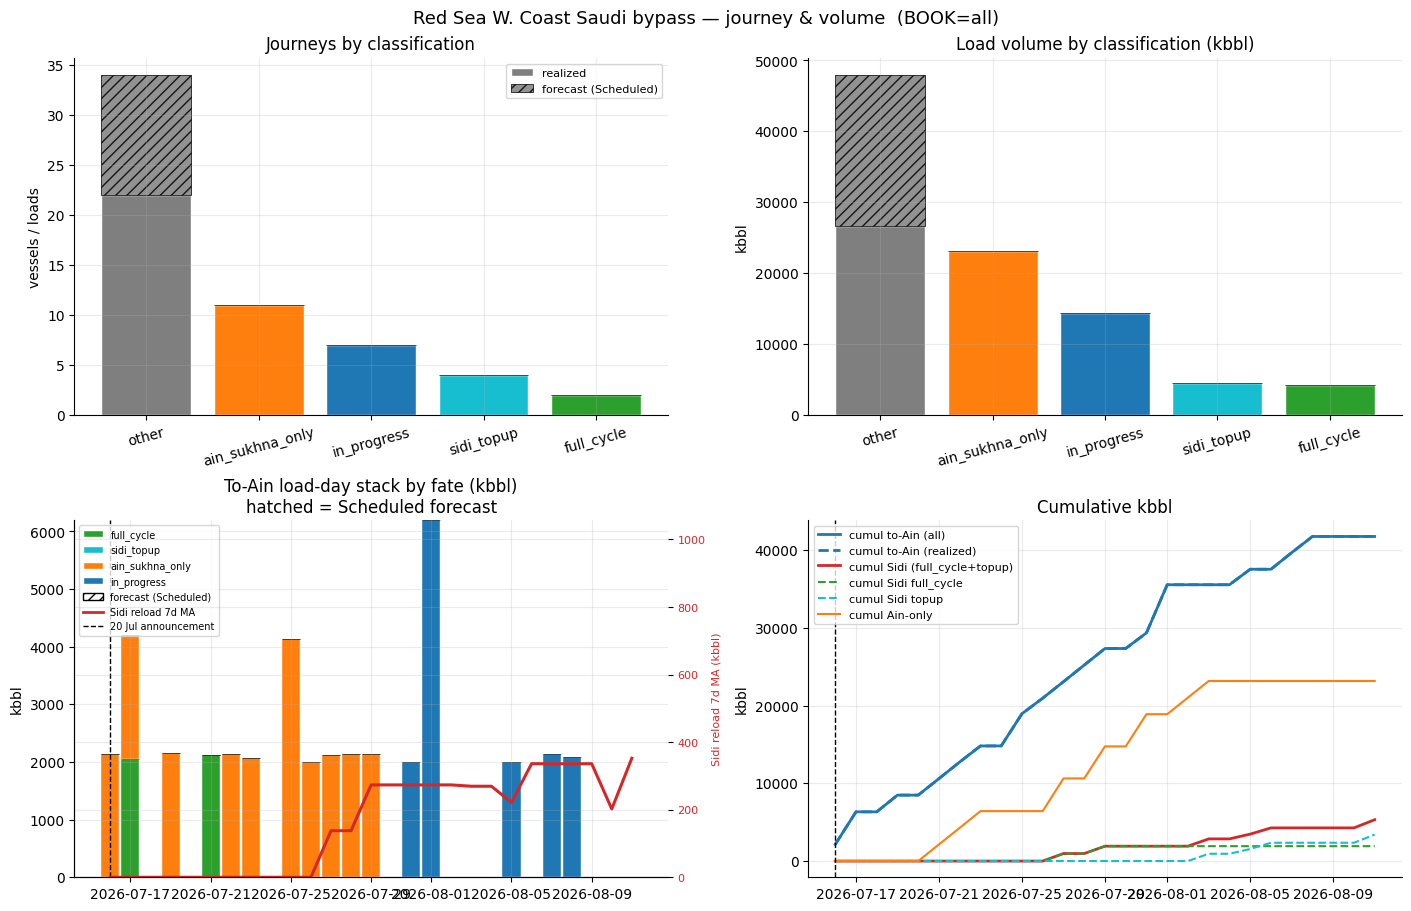

In [10]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

CLASS_ORDER = ["other", "ain_sukhna_only", "in_progress", "sidi_topup", "full_cycle"]
CLASS_COLORS = {
    "full_cycle": "#2ca02c",
    "sidi_topup": "#17becf",
    "ain_sukhna_only": "#ff7f0e",
    "in_progress": "#1f77b4",
    "other": "#7f7f7f",
}
AIN_STACK_CLASSES = ["full_cycle", "ain_sukhna_only", "in_progress"]

plot_df = chains.loc[book_mask(chains)].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)


def stacked_class_realization(ax, value_col: str | None, title: str, ylabel: str):
    """Grouped class bars: realized solid + forecast hatched on top."""
    x = np.arange(len(CLASS_ORDER))
    realized_vals = []
    forecast_vals = []
    for cls in CLASS_ORDER:
        sub = plot_df[plot_df["classification"] == cls]
        if value_col is None:
            realized_vals.append(int((sub["realization"] == "realized").sum()))
            forecast_vals.append(int((sub["realization"] == "forecast").sum()))
        else:
            realized_vals.append(float(sub.loc[sub["realization"] == "realized", value_col].sum()))
            forecast_vals.append(float(sub.loc[sub["realization"] == "forecast", value_col].sum()))

    ax.bar(x, realized_vals, color=[CLASS_COLORS[c] for c in CLASS_ORDER], edgecolor="white", label="realized")
    ax.bar(
        x,
        forecast_vals,
        bottom=realized_vals,
        color=[CLASS_COLORS[c] for c in CLASS_ORDER],
        edgecolor="black",
        linewidth=0.6,
        hatch="///",
        alpha=0.85,
        label="forecast (Scheduled)",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_ORDER, rotation=15)
    ax.set_title(title)
    ax.set_ylabel(ylabel)


stacked_class_realization(axes[0, 0], None, "Journeys by classification", "vessels / loads")
stacked_class_realization(axes[0, 1], "load_kbbl", "Load volume by classification (kbbl)", "kbbl")
axes[0, 0].legend(fontsize=8, loc="upper right")

# --- Bypass volume: stack to-Ain by class; hatch = forecast ---
ax = axes[1, 0]
bottom = np.zeros(len(vol))
for cls in AIN_STACK_CLASSES:
    real = vol[f"to_ain_{cls}_realized_kbbl"].to_numpy(dtype=float)
    fore = vol[f"to_ain_{cls}_forecast_kbbl"].to_numpy(dtype=float)
    ax.bar(vol.index, real, bottom=bottom, width=0.9, color=CLASS_COLORS[cls], edgecolor="white", linewidth=0.3)
    bottom = bottom + real
    ax.bar(
        vol.index,
        fore,
        bottom=bottom,
        width=0.9,
        color=CLASS_COLORS[cls],
        edgecolor="black",
        linewidth=0.4,
        hatch="///",
        alpha=0.85,
    )
    bottom = bottom + fore

ax.axvline(pd.Timestamp(cfg.START_DATE), color="black", ls="--", lw=1)
ax.set_title("To-Ain load-day stack by fate (kbbl)\nhatched = Scheduled forecast")
ax.set_ylabel("kbbl")
# Secondary axis: Sidi MA is small vs load spikes — keep it readable
ax2 = ax.twinx()
ax2.plot(vol.index, vol["sidi_reload_kbbl_7dma"], color="#d62728", lw=2.2, label="Sidi reload 7d MA")
sidi_max = float(vol["sidi_reload_kbbl_7dma"].max()) if len(vol) else 0.0
ax2.set_ylim(0, max(sidi_max * 3, 500))
ax2.set_ylabel("Sidi reload 7d MA (kbbl)", color="#d62728", fontsize=8)
ax2.tick_params(axis="y", labelcolor="#d62728", labelsize=8)

legend_bits = [
    Patch(facecolor=CLASS_COLORS["full_cycle"], edgecolor="white", label="full_cycle"),
    Patch(facecolor=CLASS_COLORS["sidi_topup"], edgecolor="white", label="sidi_topup"),
    Patch(facecolor=CLASS_COLORS["ain_sukhna_only"], edgecolor="white", label="ain_sukhna_only"),
    Patch(facecolor=CLASS_COLORS["in_progress"], edgecolor="white", label="in_progress"),
    Patch(facecolor="white", edgecolor="black", hatch="///", label="forecast (Scheduled)"),
    Line2D([0], [0], color="#d62728", lw=2, label="Sidi reload 7d MA"),
    Line2D([0], [0], color="black", lw=1, ls="--", label="20 Jul announcement"),
]
ax.legend(handles=legend_bits, fontsize=7, loc="upper left")

# --- Cumulative ---
ax = axes[1, 1]
ax.plot(vol.index, vol["to_ain_sukhna_load_kbbl"].cumsum(), label="cumul to-Ain (all)", color="#1f77b4", lw=2)
ax.plot(
    vol.index,
    vol["to_ain_realized_kbbl"].cumsum(),
    label="cumul to-Ain (realized)",
    color="#1f77b4",
    lw=2,
    ls="--",
)
ax.plot(vol.index, vol["sidi_reload_kbbl"].cumsum(), label="cumul Sidi (full_cycle+topup)", color="#d62728", lw=2)
ax.plot(vol.index, vol["sidi_full_cycle_kbbl"].cumsum(), label="cumul Sidi full_cycle", color="#2ca02c", ls="--")
ax.plot(vol.index, vol["sidi_topup_kbbl"].cumsum(), label="cumul Sidi topup", color="#17becf", ls="--")
ax.plot(vol.index, vol["ain_sukhna_only_kbbl"].cumsum(), label="cumul Ain-only", color="#ff7f0e")
ax.axvline(pd.Timestamp(cfg.START_DATE), color="black", ls="--", lw=1)
ax.set_title("Cumulative kbbl")
ax.set_ylabel("kbbl")
ax.legend(fontsize=8, loc="upper left")

fig.suptitle(f"Red Sea W. Coast Saudi bypass — journey & volume  (BOOK={BOOK})", fontsize=13)
plt.show()


Sidi-linked journeys (full_cycle + sidi_topup): 6


,load_date,vessel,origin,load_kbbl,capacity_kbbl,fill_ratio,ain_date,sidi_date,sidi_reload_kbbl,sidi_dest,final_destination,classification
55,2026-07-17,Front Gaula,Yanbu Crude,2057.264,2088.590988,0.985001,2026-07-21,2026-07-27,964.611,Houston,Houston,full_cycle
48,2026-07-21,Dht Mustang,Muajjiz,2122.861,2155.187390,0.985001,2026-07-25,2026-07-29,948.566,Americas,Americas,full_cycle
19,2026-07-21,Olympic Luck,Muajjiz,1200.001,2169.622481,0.553092,None,2026-08-03,937.081,,,sidi_topup
2,2026-07-23,Dht Gazelle,Yanbu Crude,1081.935,2033.203009,0.532133,None,2026-08-05,612.407,Western Europe,Western Europe,sidi_topup
46,2026-07-25,Front Empire,Muajjiz,1200.001,2033.203009,0.590202,None,2026-08-06,802.705,South-Central Asia,South-Central Asia,sidi_topup
44,2026-07-31,Sea Majesty,Muajjiz,1005.803,2087.043697,0.481927,None,2026-08-11,1049.939,Europe,Europe,sidi_topup


,classification,final_destination,n,load_kbbl,sidi_reload_kbbl
0,sidi_topup,Europe,1,1005.803,1049.939
1,full_cycle,Houston,1,2057.264,964.611
2,full_cycle,Americas,1,2122.861,948.566
3,sidi_topup,(blank),1,1200.001,937.081
4,sidi_topup,South-Central Asia,1,1200.001,802.705
5,sidi_topup,Western Europe,1,1081.935,612.407


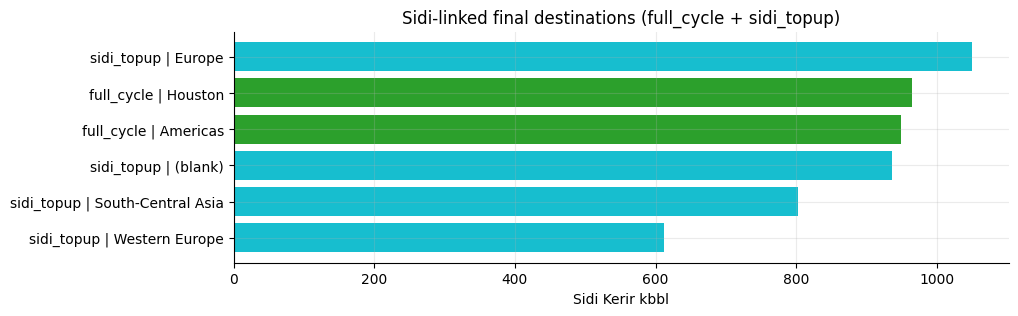


Ain-Sukhna-only journeys: 11


,load_date,vessel,origin,load_kbbl,ain_date,ain_discharge_kbbl,nominated_dest
36,2026-07-17,Amzan,Muajjiz,2141.428,2026-07-21,2141.428,Ain Sukhna
26,2026-07-16,Niban,Yanbu Crude,2130.553,2026-07-22,2130.553,Ain Sukhna
28,2026-07-19,Farhah,Muajjiz,2150.001,2026-07-23,2150.001,Ain Sukhna
11,2026-07-22,Khuzama,Yanbu Crude,2139.051,2026-07-27,2139.051,Ain Sukhna
39,2026-07-23,Dht Puma,Yanbu Crude,2065.001,2026-07-27,2065.001,Ain Sukhna
8,2026-07-27,Layla,Muajjiz,2120.842,2026-07-29,2120.842,Ain Sukhna
27,2026-07-25,Niban,Muajjiz,2000.002,2026-07-29,2000.002,Ain Sukhna
29,2026-07-26,Farhah,Muajjiz,2000.002,2026-07-31,2000.002,Ain Sukhna
37,2026-07-25,Amzan,Muajjiz,2141.428,2026-07-31,2141.428,Ain Sukhna
32,2026-07-29,Morocco Prosperity,Muajjiz,2137.271,2026-08-02,2137.271,Ain Sukhna



Sidi-topup journeys: 4


,load_date,vessel,origin,load_kbbl,capacity_kbbl,fill_ratio,sidi_date,sidi_reload_kbbl,sidi_dest,final_destination
19,2026-07-21,Olympic Luck,Muajjiz,1200.001,2169.622481,0.553092,2026-08-03,937.081,,
2,2026-07-23,Dht Gazelle,Yanbu Crude,1081.935,2033.203009,0.532133,2026-08-05,612.407,Western Europe,Western Europe
46,2026-07-25,Front Empire,Muajjiz,1200.001,2033.203009,0.590202,2026-08-06,802.705,South-Central Asia,South-Central Asia
44,2026-07-31,Sea Majesty,Muajjiz,1005.803,2087.043697,0.481927,2026-08-11,1049.939,Europe,Europe


In [11]:
completed = chains[chains["classification"].isin(cfg.SIDI_VOLUME_CLASSES)].copy()
print(f"Sidi-linked journeys (full_cycle + sidi_topup): {len(completed):,}")
if completed.empty:
    print("No Sidi-linked cycles yet — final-destination chart skipped.")
    dest_summary = pd.DataFrame(columns=["final_destination", "n", "load_kbbl", "sidi_reload_kbbl"])
else:
    display(
        completed[
            [
                c
                for c in [
                    "load_date", "vessel", "origin", "load_kbbl", "capacity_kbbl", "fill_ratio",
                    "ain_date", "sidi_date", "sidi_reload_kbbl", "sidi_dest", "final_destination",
                    "classification",
                ]
                if c in completed.columns
            ]
        ].sort_values(["classification", "load_date"])
    )
    dest_summary = (
        completed.assign(final_destination=completed["final_destination"].replace("", "(blank)"))
        .groupby(["classification", "final_destination"], dropna=False)
        .agg(n=("vessel", "count"), load_kbbl=("load_kbbl", "sum"), sidi_reload_kbbl=("sidi_reload_kbbl", "sum"))
        .sort_values("sidi_reload_kbbl", ascending=False)
        .reset_index()
    )
    display(dest_summary)

    fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * max(len(dest_summary), 1))))
    colors = dest_summary["classification"].map(
        {"full_cycle": "#2ca02c", "sidi_topup": "#17becf"}
    ).fillna("#7f7f7f")
    labels = dest_summary["classification"] + " | " + dest_summary["final_destination"].astype(str)
    ax.barh(labels, dest_summary["sidi_reload_kbbl"].fillna(0), color=colors)
    ax.invert_yaxis()
    ax.set_xlabel("Sidi Kerir kbbl")
    ax.set_title("Sidi-linked final destinations (full_cycle + sidi_topup)")
    plt.show()

ain_only = chains[chains["classification"] == "ain_sukhna_only"].copy()
print(f"\nAin-Sukhna-only journeys: {len(ain_only):,}")
if not ain_only.empty:
    display(
        ain_only[
            ["load_date", "vessel", "origin", "load_kbbl", "ain_date", "ain_discharge_kbbl", "nominated_dest"]
        ].sort_values("ain_date")
    )

topup = chains[chains["classification"] == "sidi_topup"].copy()
print(f"\nSidi-topup journeys: {len(topup):,}")
if not topup.empty:
    display(
        topup[
            [
                c
                for c in [
                    "load_date", "vessel", "origin", "load_kbbl", "capacity_kbbl", "fill_ratio",
                    "sidi_date", "sidi_reload_kbbl", "sidi_dest", "final_destination",
                ]
                if c in topup.columns
            ]
        ].sort_values("load_date")
    )


Rows with load + Ain volume: 20


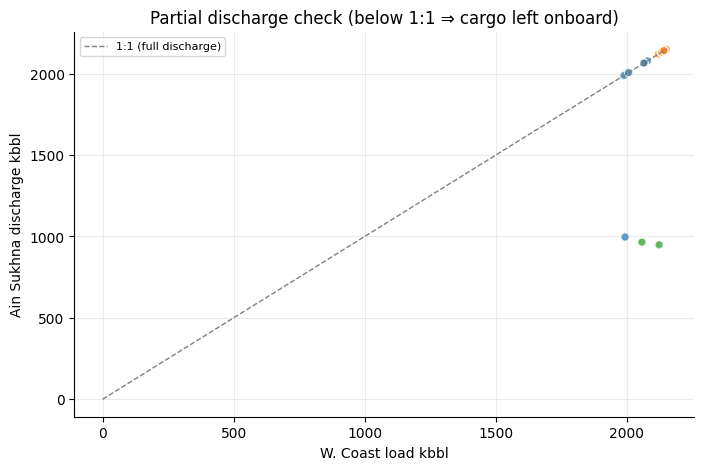

         load_kbbl  ain_discharge_kbbl  residual_onboard_kbbl
count    20.000000           20.000000              20.000000
mean   2087.307100         1924.135300             163.171800
std      60.180627          415.002272             399.562059
min    1989.102000          948.566000               0.000000
25%    2044.508500         2000.002000               0.000000
50%    2121.851500         2099.397000               0.000000
75%    2137.716000         2137.716000               0.000000
max    2150.001000         2150.001000            1174.295000


In [12]:
# Partial-discharge signal for cycles that have both load + Ain volumes
partial = chains[chains["residual_onboard_kbbl"].notna()].copy()
print(f"Rows with load + Ain volume: {len(partial):,}")
if not partial.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = partial["classification"].map(
        {
            "full_cycle": "#2ca02c",
            "sidi_topup": "#17becf",
            "ain_sukhna_only": "#ff7f0e",
            "in_progress": "#1f77b4",
            "other": "#7f7f7f",
        }
    ).fillna("#7f7f7f")
    ax.scatter(partial["load_kbbl"], partial["ain_discharge_kbbl"], c=colors, alpha=0.75, edgecolor="white")
    mx = np.nanmax([partial["load_kbbl"].max(), partial["ain_discharge_kbbl"].max()])
    ax.plot([0, mx], [0, mx], ls="--", color="gray", lw=1, label="1:1 (full discharge)")
    ax.set_xlabel("W. Coast load kbbl")
    ax.set_ylabel("Ain Sukhna discharge kbbl")
    ax.set_title("Partial discharge check (below 1:1 ⇒ cargo left onboard)")
    ax.legend(fontsize=8)
    plt.show()
    print(partial[["vessel", "load_kbbl", "ain_discharge_kbbl", "residual_onboard_kbbl", "classification"]].describe())


## 9. Top-down check — Yanbu zone + Ain Sukhna + Sidi Kerir

Sanity check on **aggregate Kpler volumes** (not journey classification):

1. **Yanbu zone** crude loads (all destinations) — total kbbl + dest mix  
2. **Yanbu → Ain Sukhna** — potential bypass / SUMED intake (top-down ceiling)  
3. **Sidi Kerir** crude loads — Med-side outturn + dest mix  
4. **Overlap** — Sidi loaders that also loaded Yanbu/W. Coast in the window  
5. **vs bottom-up** — compare Ain-bound Yanbu kbbl to classified journey volumes  

Uses existing pulls (`universe`, `ain_dest_trades`, `sidi_loads`, `chains`). Load kbbl are summed as Kpler trade parcels (splits add to a full lifting — that is intended here).

6. **Suez-side daily stack** — daily kbbl of **Sidi Kerir loads** + **Yanbu ex-Ain** (Yanbu zone loads *not* destined to Ain Sukhna), to isolate barrels leaving via waterborne/Suez paths rather than SUMED intake.

7. **Suez-side stack by destination region** — same Yanbu ex-Ain + Sidi Kerir universe, daily kbbl stacked by **USA / Europe / Asia / Other** (plus a country breakdown table).



In [13]:
# --- Top-down aggregates (trade parcels summed; not journey-collapsed) ---

def _dest_label(s: pd.Series) -> pd.Series:
    out = s.fillna("").astype(str).str.strip().replace({"": "(blank)", "nan": "(blank)"})
    return out


def _kbbl_by_dest(df: pd.DataFrame, dest_col: str = "dest_best", vol_col: str = "kbbl") -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame(columns=["destination", "n", "kbbl", "pct"])
    tmp = df.copy()
    tmp["_dest"] = _dest_label(tmp[dest_col] if dest_col in tmp.columns else pd.Series([""] * len(tmp)))
    tmp["_kbbl"] = pd.to_numeric(tmp[vol_col], errors="coerce")
    g = (
        tmp.groupby("_dest", dropna=False)
        .agg(n=("vessel_name" if "vessel_name" in tmp.columns else tmp.columns[0], "count"), kbbl=("_kbbl", "sum"))
        .sort_values("kbbl", ascending=False)
        .reset_index()
        .rename(columns={"_dest": "destination"})
    )
    total = g["kbbl"].sum()
    g["pct"] = np.where(total > 0, 100.0 * g["kbbl"] / total, 0.0)
    g["kbbl"] = g["kbbl"].round(1)
    g["pct"] = g["pct"].round(1)
    return g


# Yanbu zone only (Yanbu / Yanbu Crude / Muajjiz) within the analysis universe
yanbu_mask = universe["origin_best"].astype(str).str.lower().str.contains(
    "yanbu|muajjiz", regex=True, na=False
)
yanbu = universe.loc[yanbu_mask].copy()

# Realization first so Ain subset inherits it
if "status" in yanbu.columns:
    yanbu["realization"] = yanbu["status"].map(status_to_realization)
else:
    yanbu["realization"] = "realized"

yanbu_ain = yanbu.loc[yanbu["dest_ain_sukhna"] | yanbu["dest_best"].map(is_ain_sukhna)].copy()

# Sidi Kerir loads in window (origin pull already zone-filtered)
sidi = sidi_loads.copy() if sidi_loads is not None else pd.DataFrame()
if not sidi.empty and "load_ts" in sidi.columns:
    sidi = sidi[sidi["load_ts"].dt.date >= cfg.START_DATE].copy()

yanbu_dest = _kbbl_by_dest(yanbu)
yanbu_ain_dest = _kbbl_by_dest(yanbu_ain)
sidi_dest = _kbbl_by_dest(sidi)

yanbu_total = float(pd.to_numeric(yanbu.get("kbbl"), errors="coerce").sum())
yanbu_ain_total = float(pd.to_numeric(yanbu_ain.get("kbbl"), errors="coerce").sum())
sidi_total = float(pd.to_numeric(sidi.get("kbbl"), errors="coerce").sum()) if not sidi.empty else 0.0

print(f"Window from {cfg.START_DATE} (as of {AS_OF})")
print(f"Yanbu zone loads:     {len(yanbu):,} trades  |  {yanbu_total:,.0f} kbbl")
print(f"  of which -> Ain:    {len(yanbu_ain):,} trades  |  {yanbu_ain_total:,.0f} kbbl  "
      f"({100*yanbu_ain_total/yanbu_total:.1f}% of Yanbu)" if yanbu_total else "")
print(f"Sidi Kerir loads:     {len(sidi):,} trades  |  {sidi_total:,.0f} kbbl")

print("\n=== Yanbu zone — destinations (kbbl) ===")
display(yanbu_dest.head(20))

print("\n=== Yanbu -> Ain Sukhna — by realization ===")
if not yanbu_ain.empty:
    by_real = (
        yanbu_ain.assign(_kbbl=pd.to_numeric(yanbu_ain["kbbl"], errors="coerce"))
        .groupby("realization", dropna=False)["_kbbl"]
        .agg(["count", "sum"])
        .rename(columns={"count": "n", "sum": "kbbl"})
        .round(1)
    )
    display(by_real)
    display(
        yanbu_ain[
            [c for c in ["load_ts", "vessel_name", "vessel_type", "origin_best", "dest_best", "kbbl", "status"]
             if c in yanbu_ain.columns]
        ]
        .sort_values("load_ts")
        .reset_index(drop=True)
    )
else:
    print("No Yanbu -> Ain Sukhna trades in window.")

print("\n=== Sidi Kerir — destinations (kbbl) ===")
display(sidi_dest.head(20))

# Overlap: IMOs that loaded Yanbu/W.Coast and also loaded Sidi in window
sidi_from_yanbu = pd.DataFrame()
yanbu_imos = set(pd.to_numeric(yanbu.get("vessel_imo"), errors="coerce").dropna().astype(int))
wcoast_imos = set(pd.to_numeric(universe.get("vessel_imo"), errors="coerce").dropna().astype(int))
sidi_imos = set(pd.to_numeric(sidi.get("vessel_imo"), errors="coerce").dropna().astype(int)) if not sidi.empty else set()
overlap_yanbu = yanbu_imos & sidi_imos
overlap_wcoast = wcoast_imos & sidi_imos

print(f"\n=== IMO overlap ===")
print(f"Yanbu loaders also loading Sidi:     {len(overlap_yanbu)}")
print(f"Any W. Coast loaders also at Sidi:   {len(overlap_wcoast)}")

if overlap_yanbu and not sidi.empty:
    sidi_from_yanbu = sidi[sidi["vessel_imo"].isin(overlap_yanbu)].copy()
    print(f"Sidi kbbl on vessels that also loaded Yanbu: "
          f"{pd.to_numeric(sidi_from_yanbu['kbbl'], errors='coerce').sum():,.0f}")
    display(
        sidi_from_yanbu[
            [c for c in ["load_ts", "vessel_name", "origin_best", "dest_best", "kbbl", "status"]
             if c in sidi_from_yanbu.columns]
        ]
        .sort_values("load_ts")
        .reset_index(drop=True)
    )

# Bottom-up comparison (collapsed journeys)
bu = chains.copy() if "chains" in dir() and chains is not None else pd.DataFrame()
if not bu.empty:
    bu_ain = bu[bu["dest_ain_sukhna"] | bu["ain_date"].notna()]
    bu_sidi_classes = bu[bu["classification"].isin(cfg.SIDI_VOLUME_CLASSES)]
    compare = pd.DataFrame(
        [
            {
                "cut": "TOP-DOWN Yanbu zone total",
                "kbbl": round(yanbu_total, 1),
                "n": len(yanbu),
                "notes": "all dests",
            },
            {
                "cut": "TOP-DOWN Yanbu -> Ain Sukhna",
                "kbbl": round(yanbu_ain_total, 1),
                "n": len(yanbu_ain),
                "notes": "potential bypass ceiling",
            },
            {
                "cut": "TOP-DOWN Sidi Kerir loads",
                "kbbl": round(sidi_total, 1),
                "n": len(sidi),
                "notes": "all Sidi origin crude",
            },
            {
                "cut": "TOP-DOWN Sidi on Yanbu-overlap IMOs",
                "kbbl": round(float(pd.to_numeric(sidi_from_yanbu["kbbl"], errors="coerce").sum()), 1)
                if overlap_yanbu and not sidi.empty
                else 0.0,
                "n": int(sidi_from_yanbu["vessel_imo"].nunique()) if overlap_yanbu and not sidi.empty else 0,
                "notes": "Sidi kbbl where vessel also loaded Yanbu",
            },
            {
                "cut": "BOTTOM-UP journeys to-Ain (load kbbl)",
                "kbbl": round(float(pd.to_numeric(bu_ain["load_kbbl"], errors="coerce").sum()), 1),
                "n": len(bu_ain),
                "notes": "collapsed; dest/ain evidence",
            },
            {
                "cut": "BOTTOM-UP full_cycle + sidi_topup (Sidi kbbl)",
                "kbbl": round(float(pd.to_numeric(bu_sidi_classes["sidi_reload_kbbl"], errors="coerce").sum()), 1),
                "n": len(bu_sidi_classes),
                "notes": "classified Med re-entry",
            },
            {
                "cut": "BOTTOM-UP ain_sukhna_only (Ain kbbl)",
                "kbbl": round(
                    float(
                        pd.to_numeric(
                            bu.loc[bu["classification"] == "ain_sukhna_only", "ain_discharge_kbbl"],
                            errors="coerce",
                        ).sum()
                    ),
                    1,
                ),
                "n": int((bu["classification"] == "ain_sukhna_only").sum()),
                "notes": "stuck at Ain (7d+)",
            },
        ]
    )
    print("\n=== Top-down vs bottom-up ===")
    display(compare)

# Charts
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

ax = axes[0]
top_y = yanbu_dest.head(10).iloc[::-1]
ax.barh(top_y["destination"], top_y["kbbl"], color="#2f4b7c")
ax.set_title(f"Yanbu zone dests (top 10)\n{yanbu_total:,.0f} kbbl total")
ax.set_xlabel("kbbl")

ax = axes[1]
# Ain vs rest of Yanbu
rest = max(yanbu_total - yanbu_ain_total, 0)
ax.bar(["Yanbu -> Ain", "Yanbu other dests"], [yanbu_ain_total, rest], color=["#ff7f0e", "#7f7f7f"])
ax.set_title("Yanbu: Ain-bound vs other")
ax.set_ylabel("kbbl")
for i, v in enumerate([yanbu_ain_total, rest]):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)

ax = axes[2]
top_s = sidi_dest.head(10).iloc[::-1]
if not top_s.empty:
    ax.barh(top_s["destination"], top_s["kbbl"], color="#17becf")
ax.set_title(f"Sidi Kerir dests (top 10)\n{sidi_total:,.0f} kbbl total")
ax.set_xlabel("kbbl")

fig.suptitle("Top-down volume check — Yanbu zone / Ain / Sidi", fontsize=12)
plt.show()

# Stash for export
topdown_summary = compare if not bu.empty else pd.DataFrame(
    [
        {"cut": "TOP-DOWN Yanbu zone total", "kbbl": round(yanbu_total, 1), "n": len(yanbu)},
        {"cut": "TOP-DOWN Yanbu -> Ain Sukhna", "kbbl": round(yanbu_ain_total, 1), "n": len(yanbu_ain)},
        {"cut": "TOP-DOWN Sidi Kerir loads", "kbbl": round(sidi_total, 1), "n": len(sidi)},
    ]
)
topdown_yanbu_dest = yanbu_dest
topdown_sidi_dest = sidi_dest


# --- Suez-side daily stack: Sidi Kerir + Yanbu ex-Ain ---
# Yanbu ex-Ain = Yanbu zone loads NOT going to Ain Sukhna (waterborne exit candidates).
# Sidi = Med-side loads (top-up / SUMED outturn). Dated by each series' own load day.

yanbu_ex_ain = yanbu.loc[~(yanbu["dest_ain_sukhna"] | yanbu["dest_best"].map(is_ain_sukhna))].copy()

idx_td = pd.date_range(cfg.START_DATE, AS_OF, freq="D")


def _daily_kbbl(df: pd.DataFrame, date_col: str, vol_col: str) -> pd.Series:
    if df is None or df.empty or date_col not in df.columns:
        return pd.Series(0.0, index=idx_td)
    tmp = df.dropna(subset=[date_col]).copy()
    tmp["_d"] = pd.to_datetime(tmp[date_col]).dt.normalize()
    tmp["_v"] = pd.to_numeric(tmp[vol_col], errors="coerce").fillna(0.0)
    return tmp.groupby("_d")["_v"].sum().reindex(idx_td, fill_value=0.0)


# Prefer load_ts for trades; fall back to start
yanbu_date_col = "load_ts" if "load_ts" in yanbu.columns else "start"
sidi_date_col = "load_ts" if (not sidi.empty and "load_ts" in sidi.columns) else "start"

suez_daily = pd.DataFrame(
    {
        "yanbu_ex_ain_kbbl": _daily_kbbl(yanbu_ex_ain, yanbu_date_col, "kbbl"),
        "sidi_kerir_kbbl": _daily_kbbl(sidi, sidi_date_col, "kbbl"),
        "yanbu_to_ain_kbbl": _daily_kbbl(yanbu_ain, yanbu_date_col, "kbbl"),
    }
)
suez_daily.index.name = "date"
suez_daily["yanbu_ex_ain_kbbl_7dma"] = suez_daily["yanbu_ex_ain_kbbl"].rolling(7, min_periods=1).mean()
suez_daily["sidi_kerir_kbbl_7dma"] = suez_daily["sidi_kerir_kbbl"].rolling(7, min_periods=1).mean()
suez_daily["suez_side_total_kbbl"] = suez_daily["yanbu_ex_ain_kbbl"] + suez_daily["sidi_kerir_kbbl"]

ex_ain_total = float(suez_daily["yanbu_ex_ain_kbbl"].sum())
sidi_stack_total = float(suez_daily["sidi_kerir_kbbl"].sum())
print("\n=== Suez-side daily stack (totals in window) ===")
print(f"Yanbu ex-Ain:  {ex_ain_total:,.0f} kbbl  ({len(yanbu_ex_ain)} trades)")
print(f"Sidi Kerir:    {sidi_stack_total:,.0f} kbbl  ({len(sidi)} trades)")
print(f"Stack total:   {ex_ain_total + sidi_stack_total:,.0f} kbbl")
print(f"(Yanbu->Ain shown as line for contrast: {float(suez_daily['yanbu_to_ain_kbbl'].sum()):,.0f} kbbl)")

fig2, axes2 = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True, sharex=True)

ax = axes2[0]
ax.bar(
    suez_daily.index,
    suez_daily["yanbu_ex_ain_kbbl"],
    width=0.9,
    color="#2f4b7c",
    label="Yanbu ex-Ain (load day)",
)
ax.bar(
    suez_daily.index,
    suez_daily["sidi_kerir_kbbl"],
    bottom=suez_daily["yanbu_ex_ain_kbbl"],
    width=0.9,
    color="#17becf",
    label="Sidi Kerir (load day)",
)
ax.plot(
    suez_daily.index,
    suez_daily["yanbu_to_ain_kbbl"],
    color="#ff7f0e",
    lw=1.8,
    label="Yanbu -> Ain (contrast)",
)
ax.axvline(pd.Timestamp(cfg.START_DATE), color="black", ls="--", lw=1)
ax.set_ylabel("kbbl")
ax.set_title(
    "Daily stacked volume — Suez-side candidates\n"
    "Yanbu ex-Ain + Sidi Kerir (vs Yanbu->Ain line)"
)
ax.legend(fontsize=8, loc="upper left")

ax = axes2[1]
ax.plot(suez_daily.index, suez_daily["yanbu_ex_ain_kbbl"].cumsum(), color="#2f4b7c", lw=2, label="cumul Yanbu ex-Ain")
ax.plot(suez_daily.index, suez_daily["sidi_kerir_kbbl"].cumsum(), color="#17becf", lw=2, label="cumul Sidi Kerir")
ax.plot(
    suez_daily.index,
    suez_daily["suez_side_total_kbbl"].cumsum(),
    color="#d62728",
    lw=2,
    ls="--",
    label="cumul stack (ex-Ain + Sidi)",
)
ax.plot(
    suez_daily.index,
    suez_daily["yanbu_to_ain_kbbl"].cumsum(),
    color="#ff7f0e",
    lw=1.5,
    label="cumul Yanbu -> Ain",
)
ax.axvline(pd.Timestamp(cfg.START_DATE), color="black", ls="--", lw=1)
ax.set_ylabel("kbbl")
ax.set_title("Cumulative — Suez-side stack vs Ain-bound")
ax.legend(fontsize=8, loc="upper left")

plt.show()

print(suez_daily.tail(14).round(0).to_string())



# --- Suez-side stack by destination region (USA / Europe / Asia / Other) ---
REGION_ORDER = ["USA", "Europe", "Asia", "Other", "(blank)"]
REGION_COLORS = {
    "USA": "#2f4b7c",
    "Europe": "#1f77b4",
    "Asia": "#ff7f0e",
    "Other": "#7f7f7f",
    "(blank)": "#c7c7c7",
}


def _ensure_region(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if out.empty:
        out["dest_region"] = pd.Series(dtype=str)
        out["dest_country"] = pd.Series(dtype=str)
        return out
    if "dest_region" not in out.columns:
        country = out["destination_country_name"] if "destination_country_name" in out.columns else ""
        cont = out["continent_destination_name"] if "continent_destination_name" in out.columns else ""
        sub = out["destination_subcontinent_name"] if "destination_subcontinent_name" in out.columns else ""
        dest = out["dest_best"] if "dest_best" in out.columns else ""
        out["dest_country"] = country.map(clean_str) if hasattr(country, "map") else ""
        out["dest_continent"] = cont.map(clean_str) if hasattr(cont, "map") else ""
        out["dest_subcontinent"] = sub.map(clean_str) if hasattr(sub, "map") else ""
        out["dest_region"] = [
            dest_region_bucket(
                str(a) if pd.notna(a) else "",
                str(b) if pd.notna(b) else "",
                str(c) if pd.notna(c) else "",
                str(d) if pd.notna(d) else "",
            )
            for a, b, c, d in zip(
                out["dest_best"] if "dest_best" in out.columns else [""] * len(out),
                out.get("dest_country", pd.Series([""] * len(out))),
                out.get("dest_continent", pd.Series([""] * len(out))),
                out.get("dest_subcontinent", pd.Series([""] * len(out))),
                strict=False,
            )
        ]
    return out


yanbu_ex_reg = _ensure_region(yanbu_ex_ain)
sidi_reg = _ensure_region(sidi)

# Tag source then concat for combined Suez-side book
yanbu_ex_reg = yanbu_ex_reg.assign(suez_source="yanbu_ex_ain")
sidi_reg = sidi_reg.assign(suez_source="sidi_kerir")
suez_book = pd.concat([yanbu_ex_reg, sidi_reg], ignore_index=True, sort=False)

# Daily kbbl by region
region_daily = pd.DataFrame(index=idx_td)
for region in REGION_ORDER:
    sub = suez_book[suez_book["dest_region"] == region]
    # Use load_ts when present
    dcol = "load_ts" if "load_ts" in sub.columns else "start"
    vcol = "kbbl" if "kbbl" in sub.columns else "cargo_origin_barrels_split_by_product"
    if vcol == "cargo_origin_barrels_split_by_product" and not sub.empty:
        sub = sub.assign(kbbl=bbl_to_kbbl(sub[vcol]))
        vcol = "kbbl"
    region_daily[region] = _daily_kbbl(sub, dcol, vcol)

region_daily.index.name = "date"
region_daily["total"] = region_daily[REGION_ORDER].sum(axis=1)

print("\n=== Suez-side (Yanbu ex-Ain + Sidi) by destination region ===")
region_totals = region_daily[REGION_ORDER].sum().sort_values(ascending=False)
print((region_totals.round(0)).to_string())
print(f"Total: {region_totals.sum():,.0f} kbbl")

# Country breakdown table
_sb = suez_book.copy()
_sb["_kbbl"] = pd.to_numeric(_sb.get("kbbl"), errors="coerce")
if "dest_country" in _sb.columns:
    _sb["_country"] = _sb["dest_country"].fillna("").astype(str).replace({"": "(blank/zone)", "nan": "(blank/zone)"})
else:
    _sb["_country"] = "(blank/zone)"
if "vessel_name" not in _sb.columns:
    _sb["vessel_name"] = ""
country_tbl = (
    _sb.groupby(["dest_region", "_country"], dropna=False)
    .agg(n=("vessel_name", "size"), kbbl=("_kbbl", "sum"))
    .reset_index()
    .rename(columns={"_country": "destination_country"})
    .sort_values(["dest_region", "kbbl"], ascending=[True, False])
)
country_tbl["kbbl"] = country_tbl["kbbl"].round(1)
display(country_tbl)

# Also split totals by source x region
source_region = (
    suez_book.assign(_kbbl=pd.to_numeric(suez_book.get("kbbl"), errors="coerce"))
    .groupby(["suez_source", "dest_region"], dropna=False)["_kbbl"]
    .sum()
    .unstack(fill_value=0.0)
    .reindex(columns=REGION_ORDER, fill_value=0.0)
    .round(1)
)
print("\nSource x region (kbbl):")
display(source_region)

fig3, axes3 = plt.subplots(2, 1, figsize=(12, 7.5), constrained_layout=True, sharex=True)

ax = axes3[0]
bottom = np.zeros(len(region_daily))
for region in REGION_ORDER:
    vals = region_daily[region].to_numpy(dtype=float)
    ax.bar(
        region_daily.index,
        vals,
        bottom=bottom,
        width=0.9,
        color=REGION_COLORS[region],
        label=region,
        edgecolor="white",
        linewidth=0.2,
    )
    bottom = bottom + vals
ax.axvline(pd.Timestamp(cfg.START_DATE), color="black", ls="--", lw=1)
ax.set_ylabel("kbbl")
ax.set_title(
    "Daily stacked volume — Yanbu ex-Ain + Sidi Kerir\nby destination region (USA / Europe / Asia / Other)"
)
ax.legend(fontsize=8, loc="upper left", ncol=3)

ax = axes3[1]
for region in REGION_ORDER:
    ax.plot(
        region_daily.index,
        region_daily[region].cumsum(),
        color=REGION_COLORS[region],
        lw=2,
        label=f"cumul {region}",
    )
ax.plot(
    region_daily.index,
    region_daily["total"].cumsum(),
    color="#d62728",
    lw=2,
    ls="--",
    label="cumul total",
)
ax.axvline(pd.Timestamp(cfg.START_DATE), color="black", ls="--", lw=1)
ax.set_ylabel("kbbl")
ax.set_title("Cumulative — Suez-side book by destination region")
ax.legend(fontsize=8, loc="upper left", ncol=3)

plt.show()



# --- Vessel list by region (for Kpler webapp cross-check) ---
_vk = suez_book.copy()
_vk["_kbbl"] = pd.to_numeric(_vk.get("kbbl"), errors="coerce")
_vk["_load_date"] = pd.to_datetime(_vk.get("load_ts", _vk.get("start")), errors="coerce").dt.date

_cols_map = {
    "load_date": "_load_date",
    "vessel": "vessel_name",
    "imo": "vessel_imo",
    "vessel_class": "vessel_type",
    "origin": "origin_best" if "origin_best" in _vk.columns else "origin_location_name",
    "destination": "dest_best" if "dest_best" in _vk.columns else "destination_location_name",
    "destination_country": "dest_country",
    "destination_continent": "dest_continent",
    "dest_region": "dest_region",
    "kbbl": "_kbbl",
    "status": "status",
    "suez_source": "suez_source",  # yanbu_ex_ain | sidi_kerir
}

suez_vessels_by_region = pd.DataFrame()
for out_col, src_col in _cols_map.items():
    if src_col in _vk.columns:
        suez_vessels_by_region[out_col] = _vk[src_col]
    else:
        suez_vessels_by_region[out_col] = pd.NA

suez_vessels_by_region["kbbl"] = pd.to_numeric(suez_vessels_by_region["kbbl"], errors="coerce").round(1)
_region_rank = {r: i for i, r in enumerate(REGION_ORDER)}
suez_vessels_by_region["_rr"] = suez_vessels_by_region["dest_region"].map(_region_rank).fillna(99)
suez_vessels_by_region = (
    suez_vessels_by_region
    .sort_values(["_rr", "load_date", "vessel", "suez_source"])
    .drop(columns="_rr")
    .reset_index(drop=True)
)

print("\n=== Vessels by region (Yanbu ex-Ain + Sidi) — cross-check list ===")
print(f"Rows: {len(suez_vessels_by_region):,}")
print(suez_vessels_by_region.groupby("dest_region", dropna=False).size().reindex(REGION_ORDER).to_string())
display(suez_vessels_by_region)

print("Top-down frames ready: ..., suez_daily, region_daily, country_tbl, suez_vessels_by_region")


## 10. Export


In [14]:
univ_out = cfg.OUT_DIR / "wcoast_universe.csv"
chains_detail_out = cfg.OUT_DIR / "journey_chains_detail.csv"
chains_out = cfg.OUT_DIR / "journey_chains.csv"  # collapsed — matches charts
dest_out = cfg.OUT_DIR / "final_destinations.csv"
vol_out = cfg.OUT_DIR / "volume_daily.csv"
topdown_out = cfg.OUT_DIR / "topdown_summary.csv"
yanbu_dest_out = cfg.OUT_DIR / "topdown_yanbu_destinations.csv"
sidi_dest_out = cfg.OUT_DIR / "topdown_sidi_destinations.csv"
suez_daily_out = cfg.OUT_DIR / "topdown_suez_side_daily.csv"
region_daily_out = cfg.OUT_DIR / "topdown_suez_side_by_region_daily.csv"
country_tbl_out = cfg.OUT_DIR / "topdown_suez_side_by_country.csv"
vessels_region_out = cfg.OUT_DIR / "topdown_suez_side_vessels_by_region.csv"

universe_export = universe[
    [
        c for c in [
            "load_ts", "vessel_name", "vessel_imo", "vessel_type", "status",
            "closest_ancestor_grade", "origin_best", "dest_best", "kbbl", "dest_ain_sukhna",
        ] if c in universe.columns
    ]
].copy()
universe_export.to_csv(univ_out, index=False)
chains_detail.to_csv(chains_detail_out, index=False)
chains.to_csv(chains_out, index=False)
dest_summary.to_csv(dest_out, index=False)
vol.to_csv(vol_out)

if "topdown_summary" in dir():
    topdown_summary.to_csv(topdown_out, index=False)
    topdown_yanbu_dest.to_csv(yanbu_dest_out, index=False)
    topdown_sidi_dest.to_csv(sidi_dest_out, index=False)
if "suez_daily" in dir():
    suez_daily.to_csv(suez_daily_out)
if "region_daily" in dir():
    region_daily.to_csv(region_daily_out)
if "country_tbl" in dir():
    country_tbl.to_csv(country_tbl_out, index=False)
if "suez_vessels_by_region" in dir():
    suez_vessels_by_region.to_csv(vessels_region_out, index=False)

print("Wrote:")
for pth in (
    univ_out,
    chains_detail_out,
    chains_out,
    dest_out,
    vol_out,
    topdown_out,
    yanbu_dest_out,
    sidi_dest_out,
    suez_daily_out,
    region_daily_out,
    country_tbl_out,
    vessels_region_out,
):
    print(f"  {pth}  exists={pth.exists()}")
print(f"Detail rows={len(chains_detail):,}  collapsed journeys={len(chains):,}")


Wrote:
  C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\red_sea_yanbu_bypass\output\wcoast_universe.csv  exists=True
  C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\red_sea_yanbu_bypass\output\journey_chains_detail.csv  exists=True
  C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\red_sea_yanbu_bypass\output\journey_chains.csv  exists=True
  C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\red_sea_yanbu_bypass\output\final_destinations.csv  exists=True
  C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\red_sea_yanbu_bypass\output\volume_daily.csv  exists=True
  C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\red_sea_yanbu_bypass\output\topdown_summary.csv  exists=True
  C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\red_sea_yanbu_bypass\output\topdown_yanbu_destinations.csv  exists=True
  C:\Users\luiscarlos.gai

## Notes / next extensions

- Sidi Kerir reload volume is the cleanest **Med re-entry** proxy for completed bypass cycles; Ain-only volume is the **stuck-in-Red-Sea** proxy after the 7-day lag.
- If Kpler zone names for PortCalls fail, trade destinations alone still classify most journeys — check the PortCalls cell warnings.
- Possible follow-ups: Bab el Mandeb crossing anti-join, weekly desk HTML, vessel-level Gantt of legs.

- Charts split **realized vs forecast** (Scheduled hatched); to-Ain bars stack by fate on **load day**.

- **`chains_detail`** = uncollapsed Kpler trade rows (export). **`chains`** = collapsed journeys for charts/stats (one row per IMO×load_date; Sidi kbbl counted once; Sidi series = full_cycle only).

- **`sidi_topup`**: W. Coast load &lt; 65% of vessel capacity, no Ain Sukhna, later Sidi Kerir load. Sidi chart volume = `full_cycle` + `sidi_topup` on collapsed journeys.

- **Top-down check (§9):** Yanbu zone totals / Yanbu→Ain / Sidi Kerir dest mix vs bottom-up classified journeys — use as a ceiling / sanity check on bypass-sized flows.
